# IMPORT

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, kruskal, normaltest

load_dotenv()
path = os.getenv('DATA_PATH', r'D:\pandas\source files\project')

# rides.csv

In [2]:
df_r = pd.read_csv(os.path.join(path, 'rides.csv'), sep=',', encoding='UTF-8')

## Предобработка данных

### PEP-8 и типы данных

In [3]:
df_r.columns = df_r.columns.str.lower().str.replace(' ', '_')
df_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              102255 non-null  int64  
 1   start_date      102255 non-null  object 
 2   end_date        102255 non-null  object 
 3   start_location  102255 non-null  object 
 4   start_district  102255 non-null  object 
 5   end_location    102255 non-null  object 
 6   end_district    102255 non-null  object 
 7   distance        101022 non-null  float64
 8   promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


In [4]:
df_r['start_date'] = pd.to_datetime(df_r['start_date'])
df_r['end_date'] = pd.to_datetime(df_r['end_date'])

### Дубликаты

#### Явные дубликаты

In [5]:
df_r.duplicated().sum()

np.int64(4883)

In [6]:
df_r.duplicated().mean()

np.float64(0.047753166104346975)

In [7]:
dups = df_r[df_r.duplicated(keep=False)]

In [8]:
dups.sort_values('id')

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
16,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
17,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
45,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
44,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
81,100419,2023-04-22 11:31:18,2023-04-22 12:03:19,Цветочная,северо-западный,Коммунальная,Юго-Восточный,4801.0,0
...,...,...,...,...,...,...,...,...,...
102181,197640,2023-07-31 21:43:19,2023-07-31 21:58:08,Кирова,Ленинский,Коммунальная,Юго-Восточный,2809.0,0
102183,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102184,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102205,197662,2023-07-31 21:57:30,2023-07-31 22:26:37,Дорожная,Юго-Восточный,Сиреневая,Юго-Восточный,3700.0,0


In [9]:
df_r[df_r.duplicated(keep=False)].shape

(9766, 9)

видим что строки сдвоены, 4883 дубликатов, 9766 наблюдений

In [10]:
df_r = df_r.drop_duplicates()  # избавились от явных дубликатов, приступим к неявным

#### Неявные дубликаты

In [11]:
df_r['start_location'].unique()

array(['Шевченко', 'Чехова', 'Буденного', 'Труда', 'Первомайская',
       'Лесная', 'Пролетарская', 'Комарова', 'Западная', 'Свободы',
       'Коммунальная', 'Зеленая', 'Шоссейная', 'Центральная', 'буденного',
       'новая', 'Энтузиастов', 'ул.подгорная', 'Восточная', 'Лермонтова',
       'Школьная', 'Пушкина', 'подгорная', 'рябиновая', 'Солнечная',
       'Мичурина', 'ул труда', 'Партизанская', 'Вокзальная',
       'Комсомольская', 'майская', 'Красноармейская', 'Рабочая',
       'Почтовая', 'дачная', 'Заводская', 'Ломоносова', 'карла маркса',
       'Советская', 'Красная', 'Дзержинского', 'Рябиновая',
       'ул.советская', 'ул.энергетиков', 'Пионерская', 'ленина',
       'ул. сиреневая', 'гагарина', 'юбилейная', 'Цветочная',
       'ул. набережная', 'Сосновая', 'Спортивная', 'Новая', 'Ленина',
       'Полевая', 'ул. строительная', 'Майская', 'Озерная', 'ул.горького',
       'ул. восточная', 'пионерская', 'Энергетиков', 'ул.озерная',
       'южная', 'Некрасова', 'ул.молодежная', 'ул.

Если изучить то можно понять что тут записано 3 версии каждой из улиц, например: Буденного буденного ул.буденного

то же самое - проблема с форматом записи

In [12]:
def clean_loc(col):
    return (
        col.str.strip()
        .str.lower()
        .str.replace(r'^ул\.?\s*', '', regex=True)  
        .str.replace(r'\s+', '', regex=True)
    )

df_r['start_district'] = clean_loc(df_r['start_district'])
df_r['end_district'] = clean_loc(df_r['end_district'])
df_r['start_location'] = clean_loc(df_r['start_location'])
df_r['end_location'] = clean_loc(df_r['end_location'])

### Выбросы

In [13]:
df_r.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97372 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              97372 non-null  int64         
 1   start_date      97372 non-null  datetime64[ns]
 2   end_date        96817 non-null  datetime64[ns]
 3   start_location  97372 non-null  object        
 4   start_district  97372 non-null  object        
 5   end_location    97372 non-null  object        
 6   end_district    97372 non-null  object        
 7   distance        96191 non-null  float64       
 8   promo           97372 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2), object(4)
memory usage: 7.4+ MB


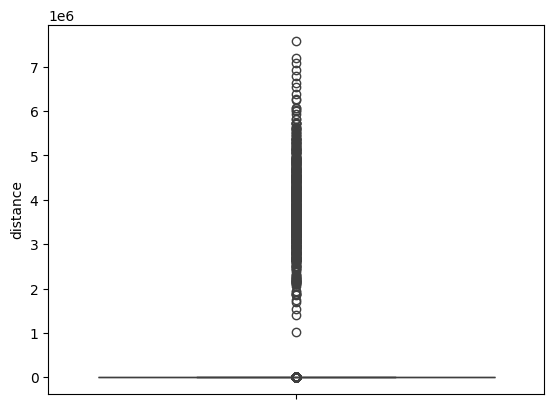

In [14]:
sns.boxplot(df_r, y='distance')
plt.show()

In [15]:
print(df_r['distance'].max())

7569789.0


смею предположить что в исходном файле distance на самом деле в мм. а не в м. Иначе большенство наших клинетов ездило от миллиона метров за поездку

In [16]:
df_r['distance'] = df_r['distance'] / 1000  # перевели в метры distance

In [17]:
max_dist = df_r['distance'].max()
row = df_r.loc[df_r['distance'] == max_dist]
print(
    row
)  # смотрим почему проехал больше всех. В целом за 42 минуты можно проехать 7569 метров

           id          start_date            end_date start_location  \
78664  175247 2023-07-10 09:57:49 2023-07-10 10:39:40         лесная   

      start_district end_location     end_district  distance  promo  
78664  юго-восточный    березовая  северо-западный  7569.789      1  


### Пропуски и выбросы


In [18]:
df_r.isna().sum()

id                   0
start_date           0
end_date           555
start_location       0
start_district       0
end_location         0
end_district         0
distance          1181
promo                0
dtype: int64

In [19]:
# Можно подметить, что мы имеем мало строк с пропуском конечной даты относительно кол-ва поездок
# Для предположения сколько ехал человек (end_date - start_date) нужно знать среднюю скорость между точками
# Но скорость не является постоянной в отличие от дистанции, ведь зависит от множества факторов
# Опытность пилота, характера вождения пилота, его целей на поездку
# Также зависит от выбранного участка (его условий и нагруженности)
# И естественно зависит от погоды.
# Исходя из вышесказанного, можно подметить, что предусмотреть оптимальную замену пропуску не является возможным с нашим уровнем погружения.
df_r.dropna(subset=['end_date'], inplace=True)

In [20]:
# Попытаемся проанализировать возможные способы работы с пропусками для дистанции.
stats = (
    df_r.groupby(['start_location', 'end_location'])['distance']
    .agg(['min', 'max', 'median', 'mean'])
    .round(2)
)
stats['range'] = stats['max'] - stats['min']
stats = stats.sort_values('range', ascending=False)

print("Группы с наибольшим разрывом (min-max):")
print(stats.head(10))
# Уже заметно, что я обнаружил новый выброс
# Удостоверяемся в этом

Группы с наибольшим разрывом (min-max):
                                 min      max  median    mean    range
start_location end_location                                           
лесная         березовая        2.90  7569.79    4.98  477.83  7566.89
садовая        полевая          0.01  7204.88    5.41  454.99  7204.87
рабочая        чкалова          3.56  7073.89    5.12  476.24  7070.33
московская     чкалова          3.57  6914.07    5.68  633.48  6910.50
лесная         новая            3.12  6784.24    5.15  682.69  6781.12
полевая        пионерская       1.53  6627.16    4.99  233.19  6625.63
пионерская     партизанская     0.00  6543.72    4.92  368.05  6543.72
сиреневая      московская       4.13  6377.04    4.76  535.92  6372.91
красная        красноармейская  0.01  6263.48    5.18  630.53  6263.47
мичурина       шоссейная        2.96  6258.73    5.27  289.32  6255.77


In [21]:
print("Первая")
print(
    df_r[(df_r['start_location'] == "лесная") & (df_r['end_location'] == "березовая")][
        'distance'
    ]
)
# Да, выброс по группам.
# Одновременно уберем выбросы по группам с помощью тройного интерквартильного размаха и заполним пропуски

Первая
3654        6.834
5649        4.216
16617       6.396
18119       5.114
24337       3.812
34641       2.896
37483       4.524
54711       7.278
57803       6.398
64190       3.189
68961       5.863
70870       4.034
78512       4.838
78664    7569.789
94709       4.711
97333       5.408
Name: distance, dtype: float64


In [22]:
def fill_outliers_and_missing(group_cols, target_col):
    df_clean = df_r.copy()
    for name, group in df_r.groupby(group_cols):
        data = group[target_col].dropna()
        if len(data) > 0:
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 3 * IQR
            upper = Q3 + 3 * IQR
            idx = group.index
            df_clean.loc[idx, target_col] = df_clean.loc[idx, target_col].fillna(
                data[(data >= lower) & (data <= upper)].median()
            )
            df_clean.loc[idx, target_col] = df_clean.loc[idx, target_col].clip(
                lower, upper
            )
    return df_clean


df_r = fill_outliers_and_missing(['start_location', 'end_location'], 'distance')

In [23]:
df_r.isna().sum()

id                0
start_date        0
end_date          0
start_location    0
start_district    0
end_location      0
end_district      0
distance          0
promo             0
dtype: int64

In [24]:
# Проверим
stats = (
    df_r.groupby(['start_location', 'end_location'])['distance']
    .agg(['min', 'max', 'median', 'mean', 'count'])
    .round(1)
)
stats['range'] = stats['max'] - stats['min']
stats = stats.sort_values('range', ascending=False)

print("Группы с наибольшим разрывом (min-max) после удаления выбросов:")
print(stats.head(100))
# Тут тяжелее, возможно стоит полностью удалить такие поездки, ведь мы не можем с уверенностью сказать, что является выбросом, а что реальностью
# Возможно имеет смысл сопоставить со средней дистанцией между районами нахождения двух точек
# TO DO

Группы с наибольшим разрывом (min-max) после удаления выбросов:
                              min     max  median    mean  count   range
start_location  end_location                                            
комарова        молодежная    3.8  5827.9     4.1  1945.3      3  5824.1
вишневая        крупской      3.0  5722.5     4.4  1910.0      3  5719.5
железнодорожная молодежная    3.9  5523.8     4.1  1384.0      4  5519.9
гагарина        энергетиков   4.0  5262.9  2633.4  2633.4      2  5258.9
кооперативная   вишневая      4.2  4553.1     4.5  1520.6      3  4548.9
...                           ...     ...     ...     ...    ...     ...
маяковского     озерная       0.0     9.1     3.9     4.0     13     9.1
центральная     северная      3.1    12.2     5.0     6.0      5     9.1
заводская       парковая      2.5    11.6     4.9     5.4     13     9.1
полевая         пионерская    1.5    10.6     4.9     5.0     31     9.1
ломоносова      северная      0.0     9.0     3.9     3.8   

In [25]:
print(
    df_r[(df_r['start_location'] == "вишневая") & (df_r['end_location'] == "крупской")][
        'distance'
    ]
)

13872    5722.498
17694       3.027
77240       4.350
Name: distance, dtype: float64


In [26]:
# посмотрим что с расстоянием по райнонам
stats_district = (
    df_r.groupby(['start_district', 'end_district'])['distance']
    .agg(['max', 'min', 'median', 'count'])
    .round(1)
)
stats_district['range'] = stats_district['max'] / stats_district['median']
stats_district = stats_district.sort_values('range', ascending=False)

print("Группы с наибольшим разрывом (min-max) после удаления выбросов:")
print(stats_district.head(100))

Группы с наибольшим разрывом (min-max) после удаления выбросов:
                                    max  min  median  count        range
start_district  end_district                                            
ленинский       юго-восточный    5827.9  0.0     4.0   2963  1456.975000
юго-восточный   центральный      5722.5  0.0     4.0   4634  1430.625000
центральный     юго-восточный    5523.8  0.0     4.0   4911  1380.950000
                центральный      3629.5  0.0     3.0   6015  1209.833333
ленинский       центральный      4071.4  0.0     3.5   3896  1163.257143
центральный     ленинский        3097.0  0.0     3.5   3925   884.857143
                октябрьский      2891.1  0.0     3.5   3602   826.028571
юго-восточный   северо-западный  4044.4  0.0     5.0   2950   808.880000
северо-западный центральный        18.1  0.0     4.0   3969     4.525000
                юго-восточный      19.6  0.0     5.1   2908     3.843137
юго-восточный   октябрьский        10.7  0.0     3.5   2593 

## Добавление итоговой_стоимости

In [27]:
def get_rate(hour, weekday):
    is_weekend = weekday >= 5

    if 1 < hour < 6:
        return 3
    elif 5 < hour < 10:
        return 4
    elif 9 < hour < 16:
        return 6 if is_weekend else 5
    elif 15 < hour < 22:
        return 7 if is_weekend else 6
    elif hour > 21 or hour < 1:
        return 6 if is_weekend else 5
    else:
        return 0

def calc_cost(row):
    distance = row['distance']
    start = row['start_date']
    end = row['end_date']
    hour = start.hour
    weekday = start.weekday()
    duration = (end - start).total_seconds() / 60
    promo = row['promo']

    rate = get_rate(hour, weekday)

    base = 0 if promo else 30
    return base + duration * rate
            

df_r['total_cost'] = df_r.apply(calc_cost, axis=1)

# weather.csv

In [28]:
df_w = pd.read_csv(os.path.join(path, 'weather.csv'), sep=',', encoding='UTF-8')

## Предобработка данных

### PEP-8 и типы данных

In [29]:
df_w.columns = df_w.columns.str.lower().str.replace(' ', '_')

In [30]:
df_w.info()  # ,°C,mm,km/h,km/h,%,min

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   datetime             3672 non-null   object
 1   temperature          3618 non-null   object
 2   precipitation_total  3643 non-null   object
 3   wind_gust            3673 non-null   object
 4   wind_speed           3657 non-null   object
 5   cloud_cover_total    3653 non-null   object
 6   sunshine_duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


In [31]:
df_w = df_w.drop(0)
df_w.head(5)  # строка с индексом 0 имеет записи об еденицах измерения, нужно её удалить

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
1,2023-04-01T00:00:00,8.740245,0.1,48.6,21.638964,90,0
2,2023-04-01T01:00:00,9.040245,0.2,55.44,22.493519,74,0
3,2023-04-01T02:00:00,8.880245,0.3,55.8,22.26477,72,0
4,2023-04-01T03:00:00,8.690246,0.3,55.44,21.94524,77,0
5,2023-04-01T04:00:00,8.630245,0.3,48.96,22.42427,78,0


In [32]:
df_w['datetime'].unique()  # нам нужно поменять формат на datetime

array(['2023-04-01T00:00:00', '2023-04-01T01:00:00',
       '2023-04-01T02:00:00', ..., '2023-08-31T21:00:00',
       '2023-08-31T22:00:00', '2023-08-31T23:00:00'], dtype=object)

#### приведение типов данных

In [33]:
df_w['datetime'] = pd.to_datetime(df_w['datetime'])
df_w['temperature'] = df_w['temperature'].astype(
    float
)  # температура у нас не string а float должна быть
df_w['precipitation_total'] = df_w['precipitation_total'].astype(
    float
)  # тоже тип float потому что наблюдения: 1.9 (пример)
df_w['wind_gust'] = df_w['wind_gust'].astype(float)
df_w['wind_speed'] = df_w['wind_speed'].astype(float)
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].astype(
    float
)  # на первый взгляд целочисленные, но там еще есть десятичные
df_w['sunshine_duration'] = df_w['sunshine_duration'].astype(
    float
)  # данные в вещественном формате

### Дубликаты

#### Явные дубликаты

In [34]:
df_w.duplicated().sum()  # явных дубликатов не обнаружено

np.int64(0)

#### Неявные дубликаты

In [35]:
df_w['temperature'].unique()

array([ 8.740245,  9.040245,  8.880245, ..., 14.290245, 15.410245,
       19.980246])

In [36]:
# Т. к. мы имеем дату, то ввиду отсутствия явных дубликатов и категориальных можно сделать вывод, что неявные дубликаты отсутствуют.

### Выбросы

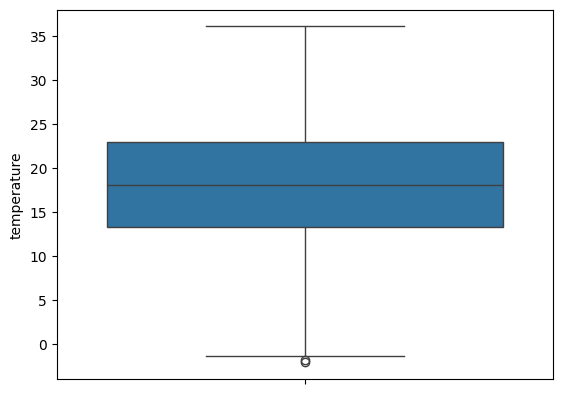

In [37]:
sns.boxplot(df_w, y='temperature')
plt.show()

### Пропуски

In [38]:
df_w.isna().sum()

datetime                0
temperature            55
precipitation_total    30
wind_gust               0
wind_speed             16
cloud_cover_total      20
sunshine_duration      12
dtype: int64

In [39]:
def missing_all(col):
    df_w.isna().sum()
    plt.figure(figsize=(15, 5))
    missing_mask = df_w[col].isnull()
    plt.scatter(
        df_w.loc[~missing_mask, 'datetime'],
        df_w.loc[~missing_mask, col],
        c='blue',
        s=10,
        alpha=0.5,
        label='Есть данные',
    )
    plt.scatter(
        df_w.loc[missing_mask, 'datetime'],
        [0] * missing_mask.sum(),
        c='red',
        s=20,
        alpha=0.7,
        label='Пропуски',
        marker='x',
    )
    plt.title('Пропуски в столбце temperature', fontsize=14)
    plt.xlabel('Дата и время', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

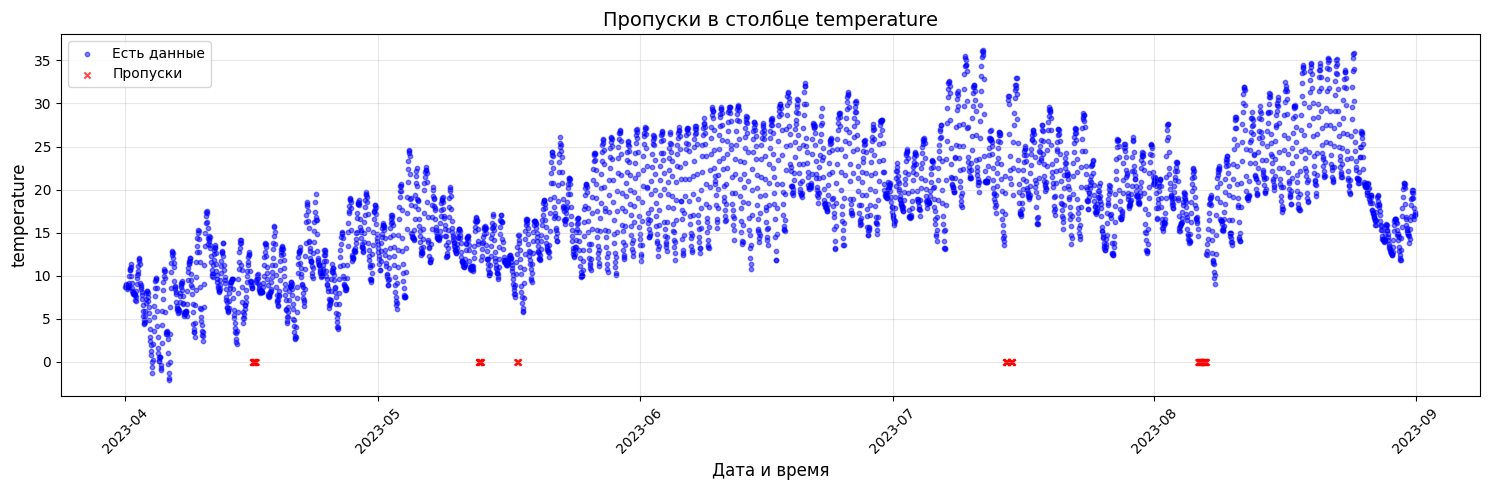

In [40]:
# Температура
missing_all('temperature')
# Видно, что имеются группы выбросов. Далее детально рассматриваем каждую.

In [41]:
def missing_groups(column):
    missing = df_w[column].isnull()
    groups = []
    flag = None

    for i, is_miss in enumerate(missing):
        if is_miss and flag is None:
            flag = i
        elif not is_miss and flag is not None:
            groups.append((flag, i - 1))
            flag = None
    if flag is not None:
        groups.append((flag, len(missing) - 1))

    pad = len(groups)
    rows = (len(groups) + 1) // 2
    fig, axes = plt.subplots(rows, min(2, len(groups)), figsize=(15, 4 * rows))
    axes = [axes] if len(groups) == 1 else axes.flatten()

    for i, (s, e) in enumerate(groups):
        start_idx = max(0, s - pad)
        end_idx = min(len(df_w), e + pad)
        subset = df_w.iloc[start_idx:end_idx]

        axes[i].plot(
            subset['datetime'][subset[column].notna()],
            subset[column].dropna(),
            'o-',
            color='blue',
            markersize=3,
        )
        axes[i].axvspan(
            subset['datetime'].iloc[s - start_idx],
            subset['datetime'].iloc[e - start_idx],
            alpha=0.2,
            color='red',
        )
        axes[i].set_title(f'Группа {i+1}: {e-s+1} пропусков')
        axes[i].set_xlabel('Дата')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

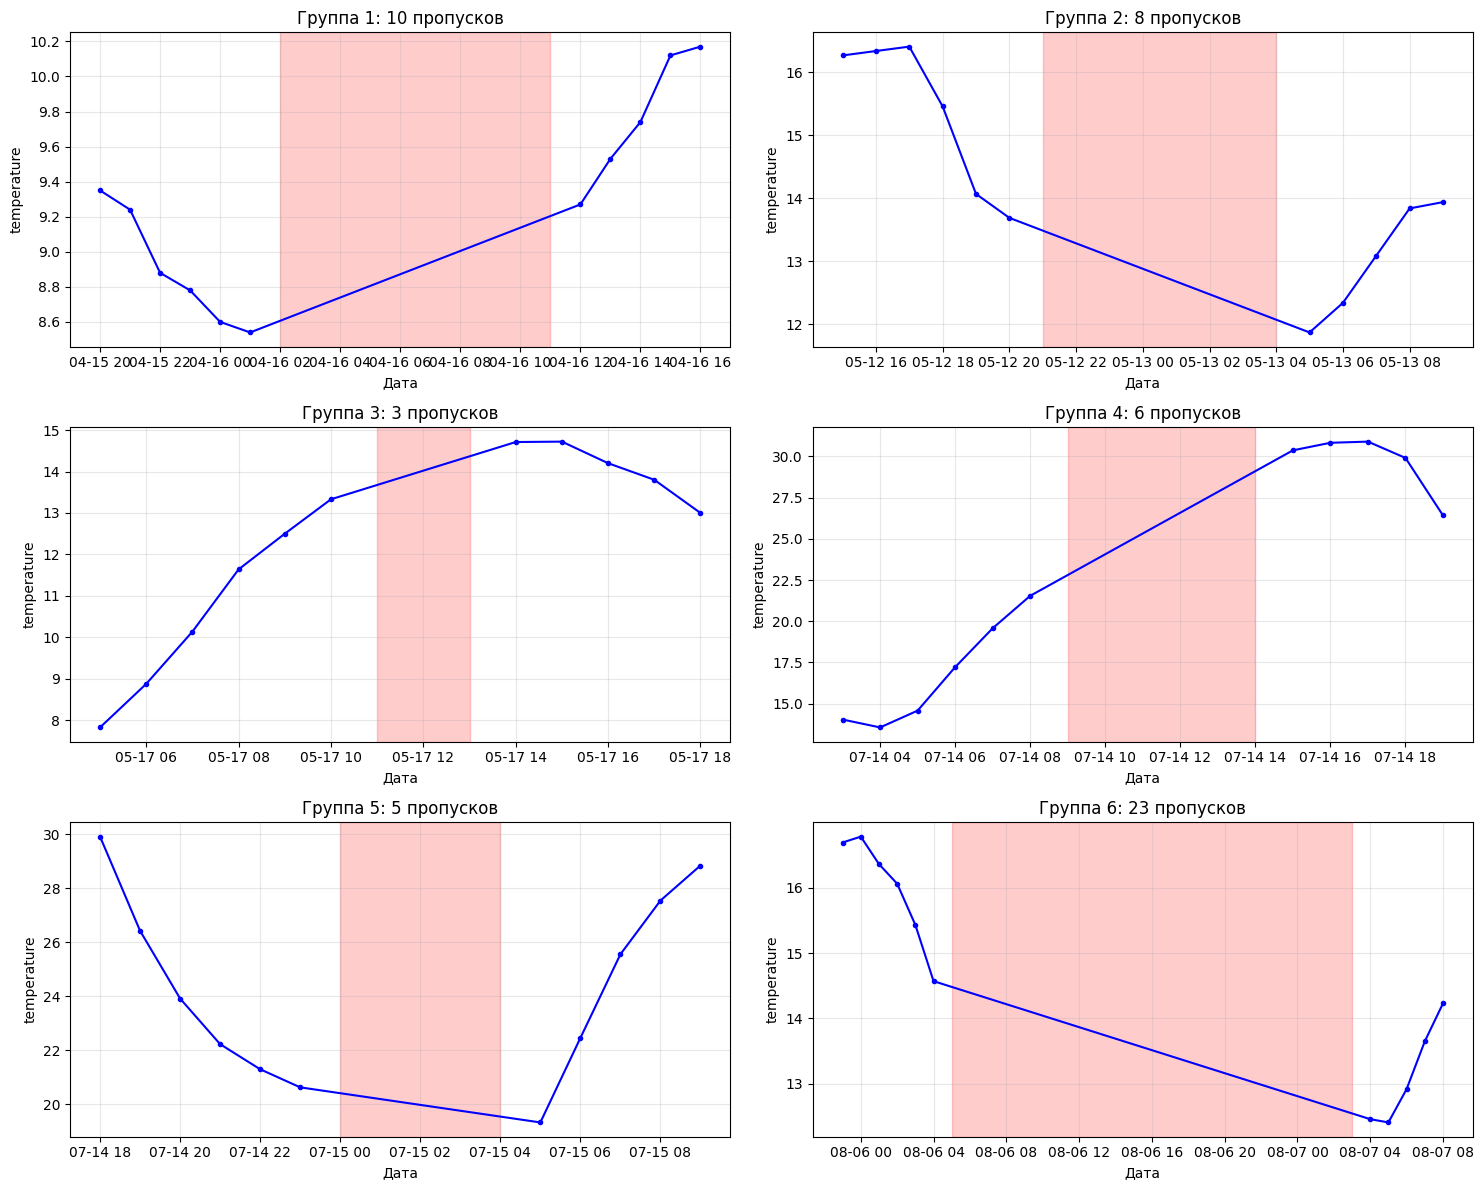

In [42]:
missing_groups(
    'temperature'
)  # Видно трендовость пропусков по группам, значит заполнение интерполяцией будет оптимально.

In [43]:
df_w['temperature'] = df_w['temperature'].interpolate(
    method='linear', limit_direction='both'
)

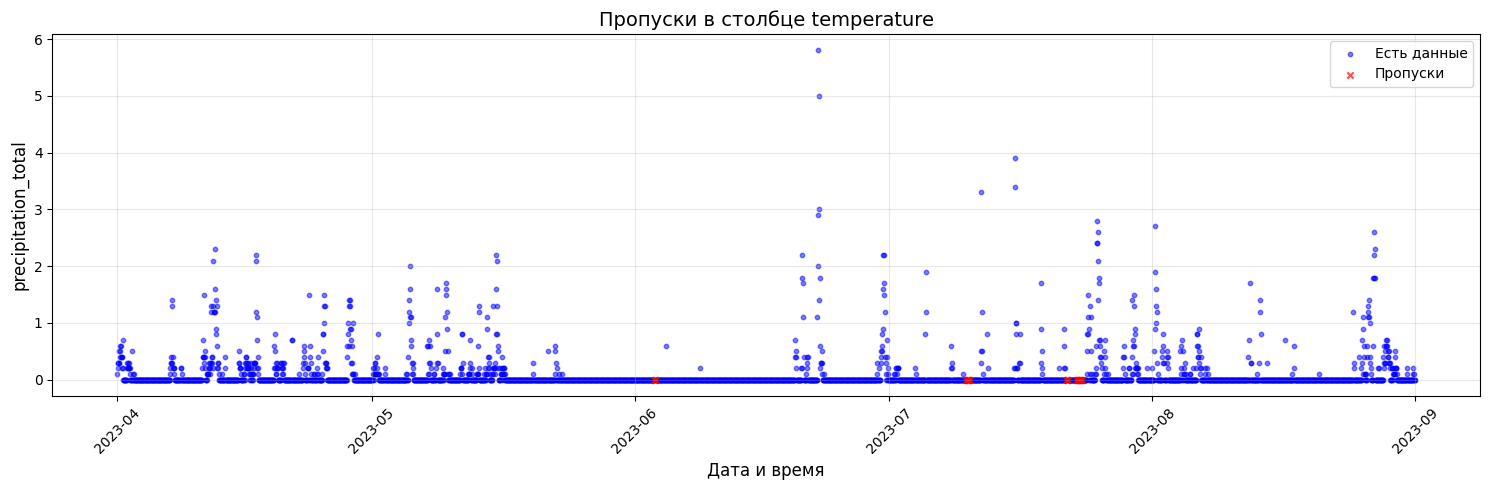

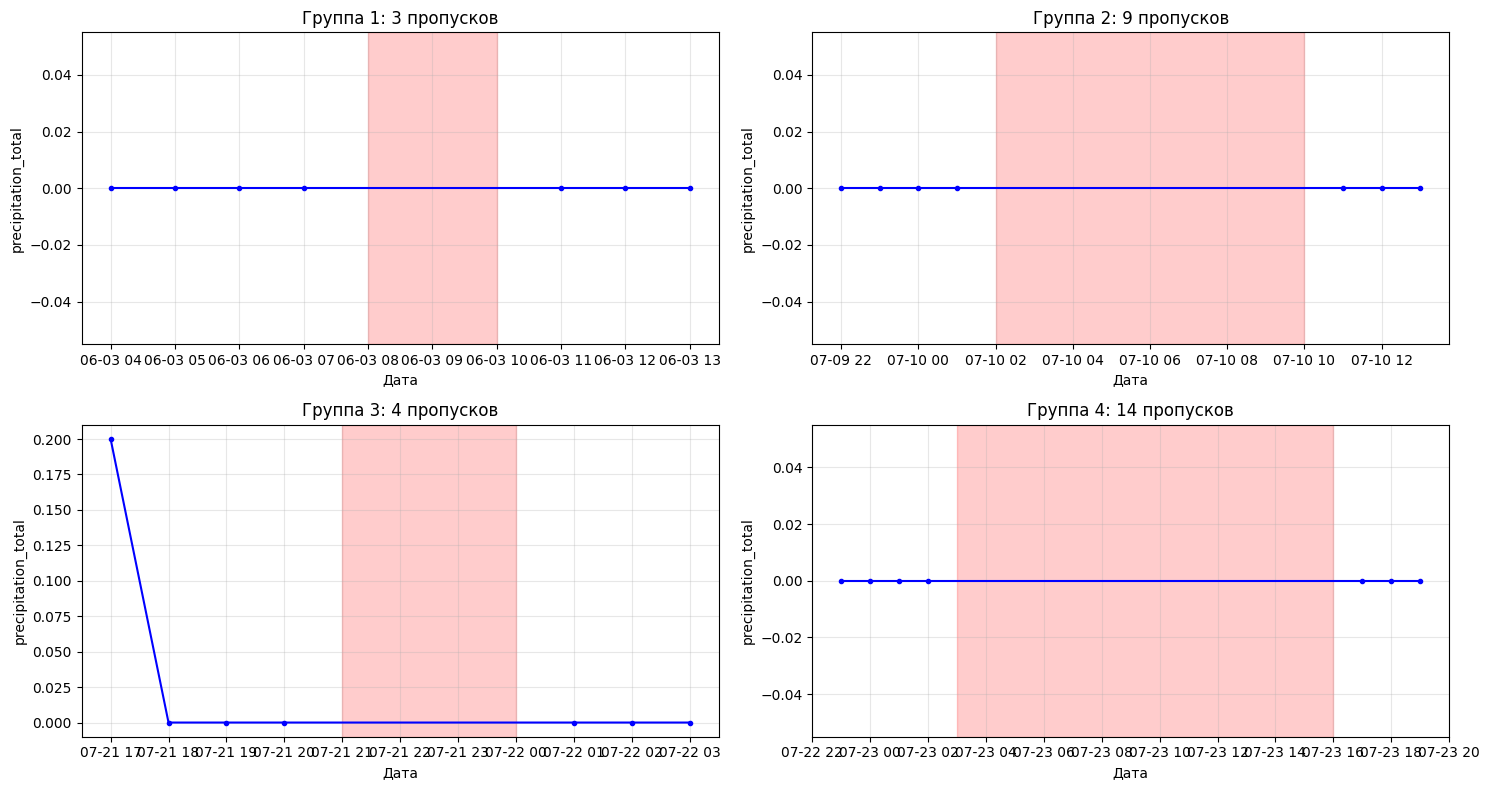

In [44]:
missing_all('precipitation_total')
missing_groups('precipitation_total')
# Аналогично температуре.

In [45]:
df_w['precipitation_total'] = df_w['precipitation_total'].interpolate(
    method='linear', limit_direction='both'
)

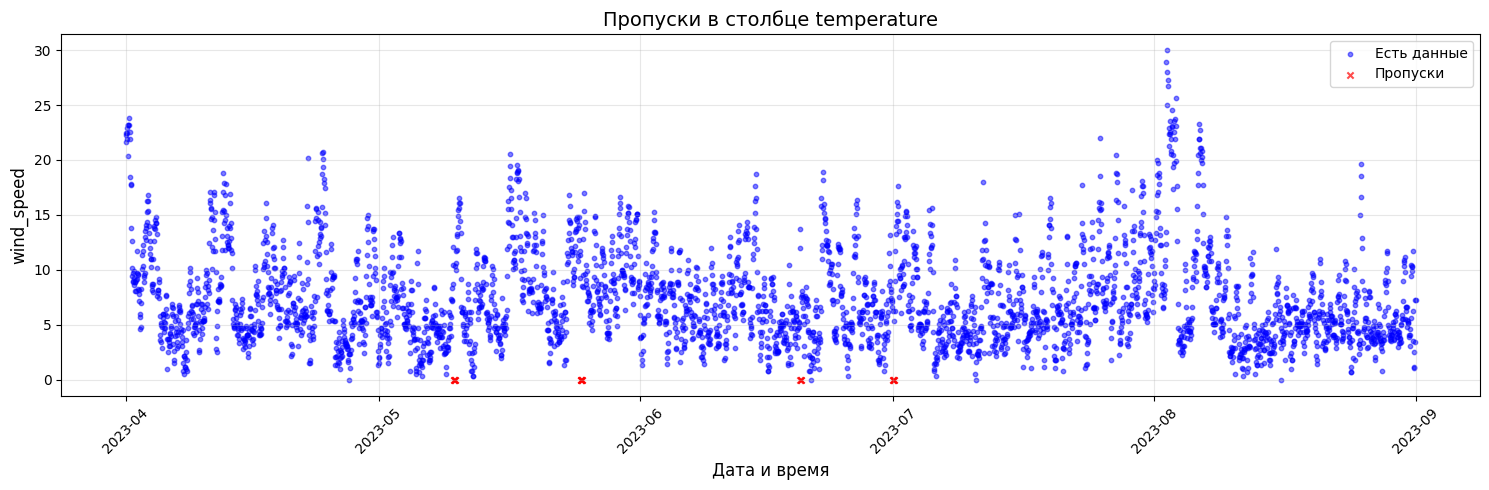

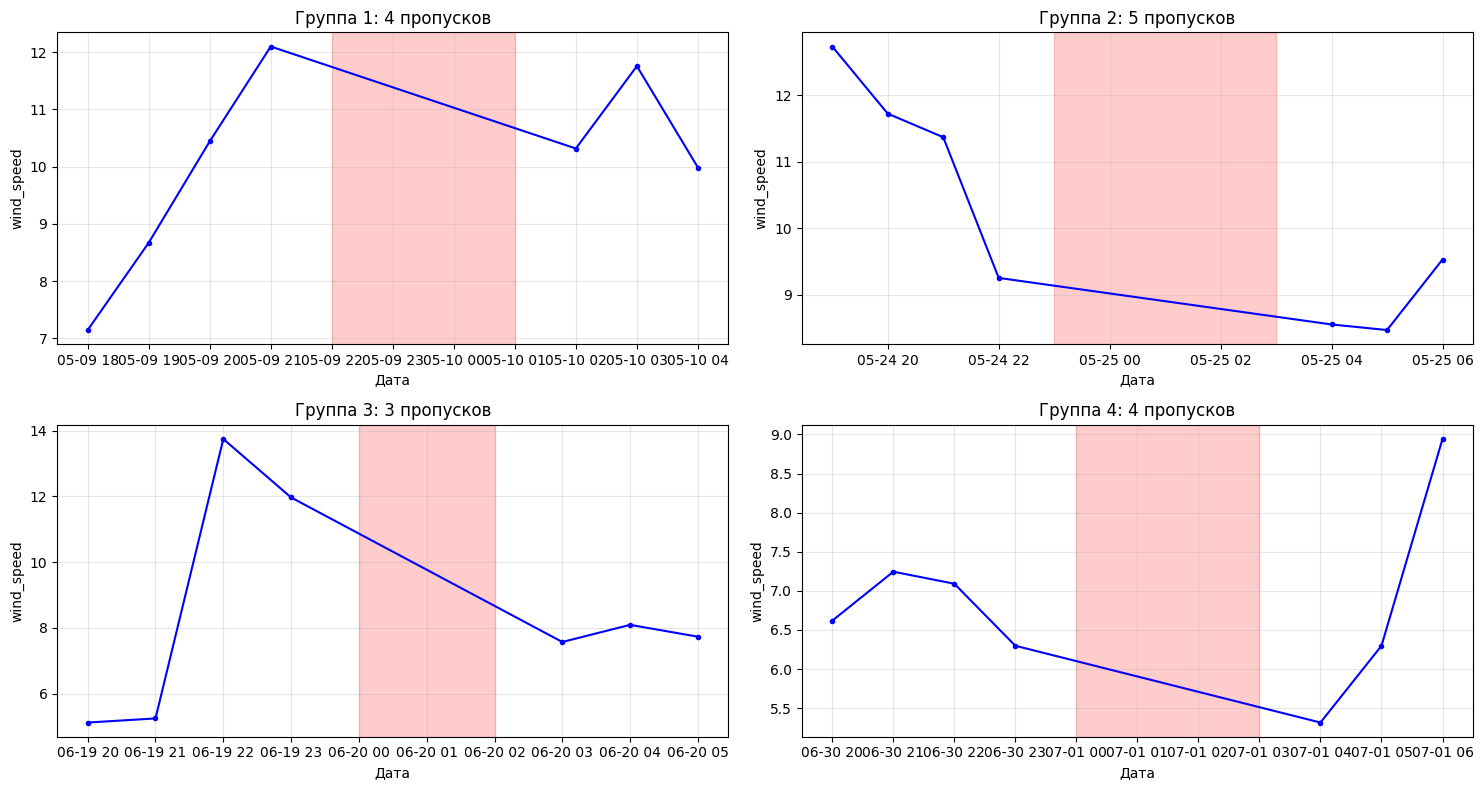

In [46]:
missing_all('wind_speed')
missing_groups('wind_speed')
# Аналогично предыдущим

In [47]:
df_w['wind_speed'] = df_w['wind_speed'].interpolate(
    method='linear', limit_direction='both'
)

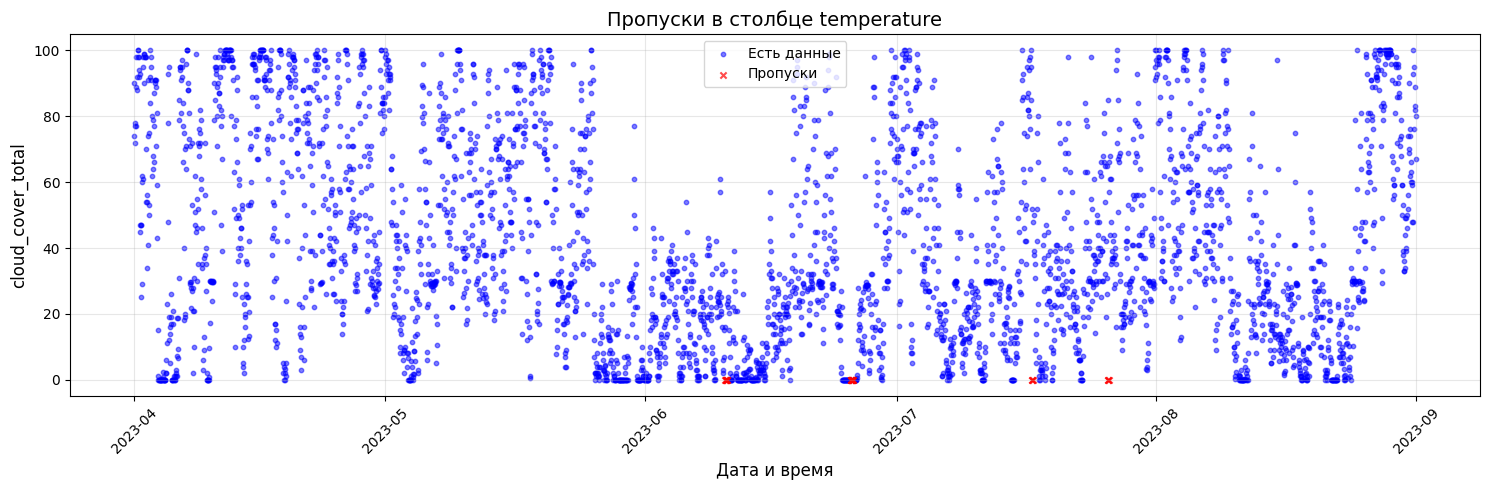

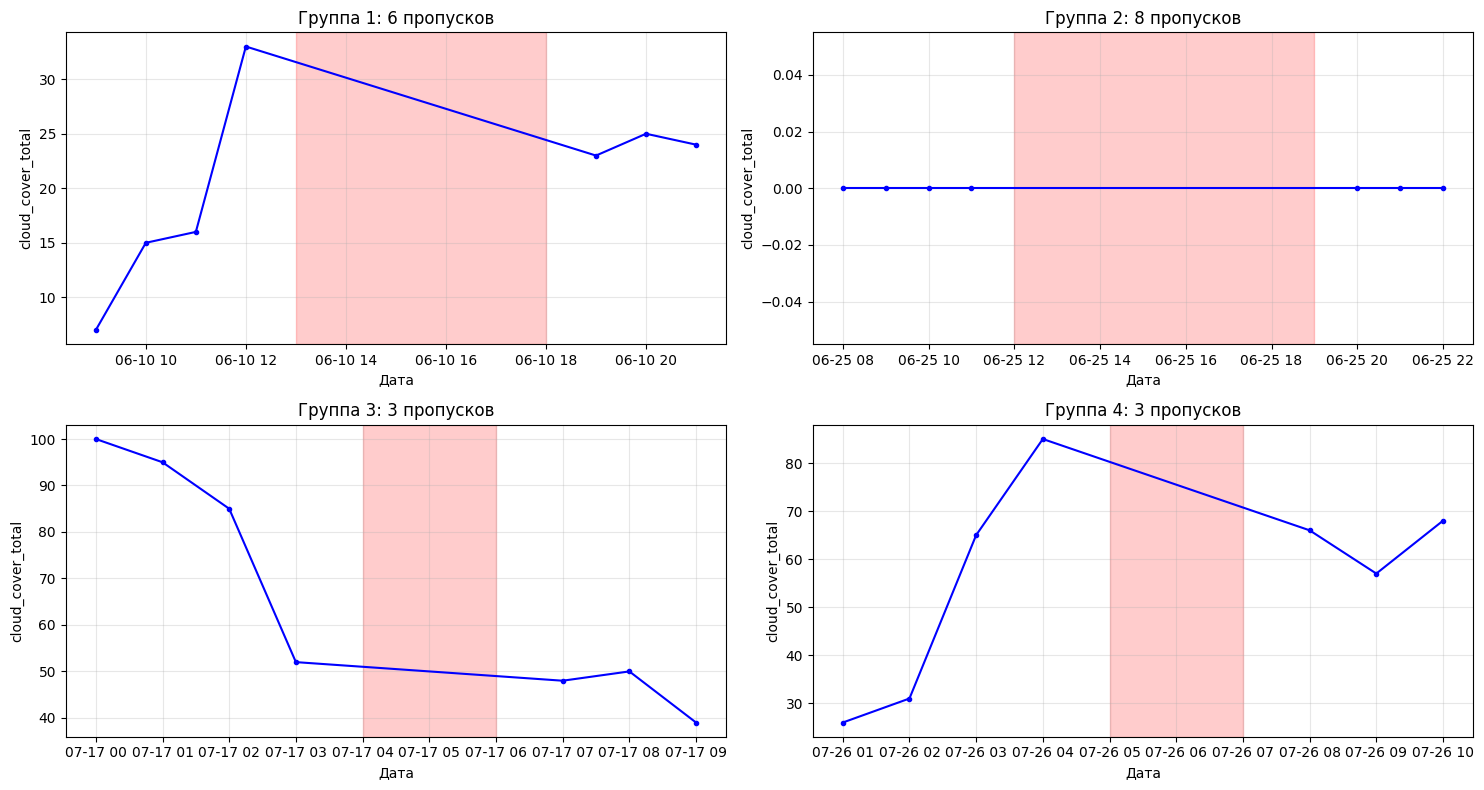

In [48]:
missing_all('cloud_cover_total')
missing_groups('cloud_cover_total')
# Аналогично предыдущим

In [49]:
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].interpolate(
    method='linear', limit_direction='both'
)

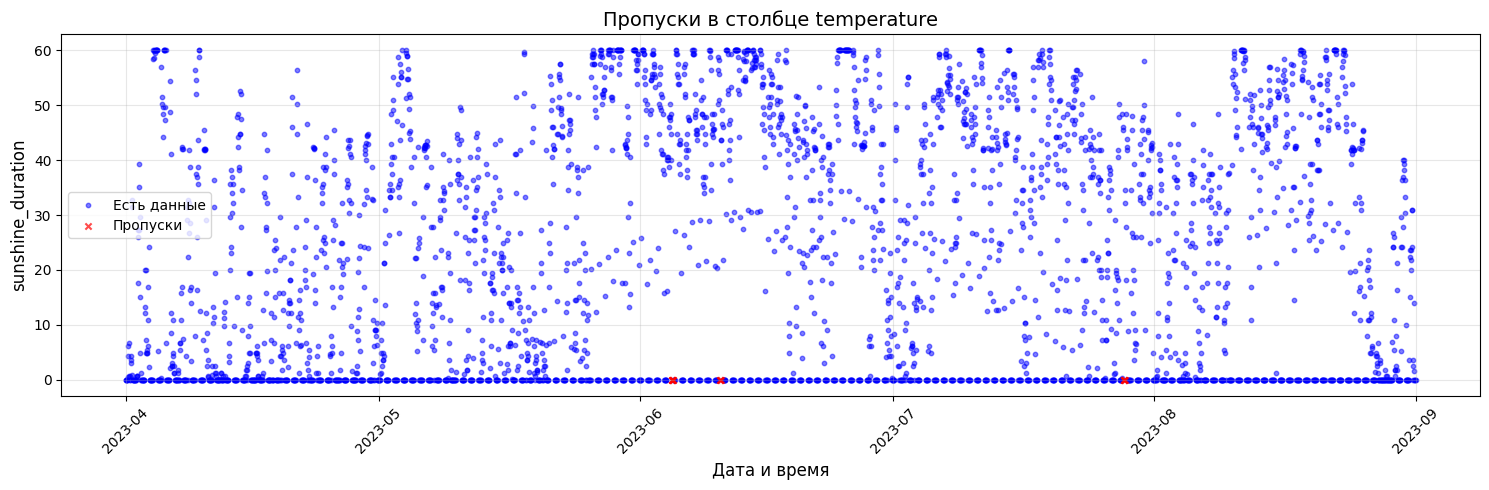

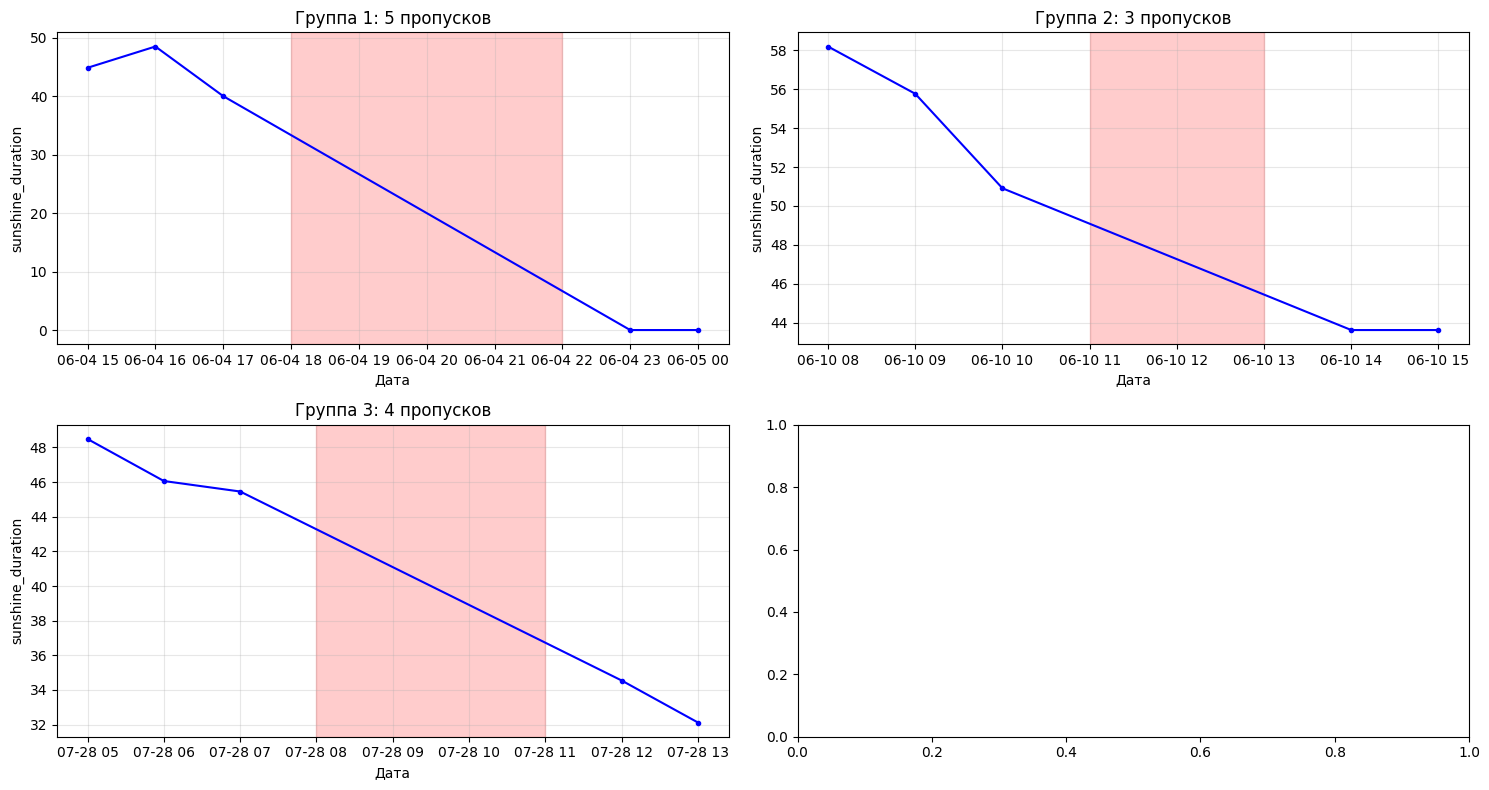

In [50]:
missing_all('sunshine_duration')
missing_groups('sunshine_duration')
# Аналогично предыдущим

In [51]:
df_w['sunshine_duration'] = df_w['sunshine_duration'].interpolate(
    method='linear', limit_direction='both'
)

In [52]:
# Смею предположить, что происходили сбои в сборе определенного типа дынных. Они были относительно кратковременны.

In [53]:
df_w.isna().sum()

datetime               0
temperature            0
precipitation_total    0
wind_gust              0
wind_speed             0
cloud_cover_total      0
sunshine_duration      0
dtype: int64

# Гипотезы

## Спрос в дождливые дни

In [54]:
# мы должны взять похожие дни, один день дождливый, другой день обычный (например, понедельник и вторник дождливый)
# возьмем некоторое количество пар, для более гарантированного исследования
# думаю, что лучше написать функцию для того чтобы находить дождливые дни, одного дня недели

In [55]:
def search_rain_day(df_w, weekdays):
    df_daily = df_w.groupby(df_w['datetime'].dt.floor('D')).agg({
        'precipitation_total': 'sum'
    }).reset_index()
    
    df_daily['weekday'] = df_daily['datetime'].dt.weekday
    
    pairs = []

    for weekday in weekdays:
        rainy_days = df_daily[
            (df_daily['weekday'].isin(weekdays)) & 
            (df_daily['precipitation_total'] > 0)
        ]
        
        non_rainy_days = df_daily[
            (df_daily['weekday'].isin(weekdays)) & 
            (df_daily['precipitation_total'] == 0)
        ]

        for rain_day in rainy_days.itertuples():
            if not non_rainy_days.empty:
                non_rain_day = non_rainy_days.iloc[0]
                pairs.append({
                    'rainy_day': rain_day.datetime.date(),  
                    'non_rain_day': non_rain_day.datetime.date(),  
                })
                non_rainy_days = non_rainy_days.drop(non_rain_day.name)

    return pairs


def compare_demand(rides_df, rain_pairs): # соеденяем в датафрейм наблюдений из rides.csv
    demand_comparison = []

    for pair in rain_pairs:
        rainy_day = pair['rainy_day']
        non_rain_day = pair['non_rain_day']
        
        rainy_demand = rides_df[rides_df['start_date'].dt.date == rainy_day].shape[0]
        non_rainy_demand = rides_df[rides_df['start_date'].dt.date == non_rain_day].shape[0]
        
        demand_comparison.append({
            'rainy_day': rainy_day,
            'non_rain_day': non_rain_day,
            'rainy_demand': rainy_demand,
            'non_rainy_demand': non_rainy_demand,
        })

    return pd.DataFrame(demand_comparison)


def test_normality(df_comparison): # Проверка нормальности, выбор теста
    rainy_demand = df_comparison['rainy_demand']
    non_rainy_demand = df_comparison['non_rainy_demand']
    
    stat_rainy, p_rainy = shapiro(rainy_demand)
    stat_non_rainy, p_non_rainy = shapiro(non_rainy_demand)
    
    if p_rainy < 0.05 or p_non_rainy < 0.05:
        stat, p = mannwhitneyu(rainy_demand, non_rainy_demand)
    else:
        stat, p = ttest_ind(rainy_demand, non_rainy_demand)

    return stat, p


rain_pairs = search_rain_day(df_w, [0, 1, 2, 3, 4])  
df_comparison = compare_demand(df_r, rain_pairs)

stat, p = test_normality(df_comparison)
print(stat, round(p, 4)) 
# 0.0075 < 0.05 соответственно, в будние дни(в выходные p-val=0.0002, если сравнивать отдельно - H1 тоже)
# спрос действительно выше в дождливые дни

31700.0 0.0075


## Отличие ср.стоимости по районам

## Спрос на самокаты дни недели

### Графически

In [57]:
def how_much_on_day(df_r, weekdays):
    result = {}
    for weekday in weekdays:
        result[weekday] = (df_r['start_date'].dt.weekday == weekday).sum()
    return result 

num = how_much_on_day(df_r, [0, 1, 2, 3, 4, 5, 6])

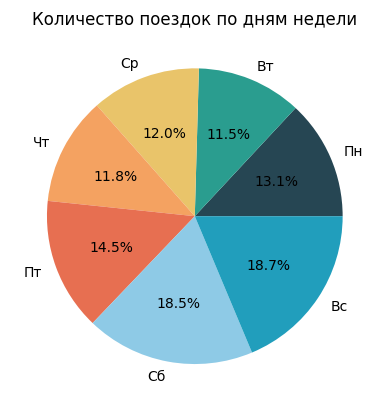

In [58]:
values = list(num.values())
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#8ECAE6', '#219EBC']
plt.pie(values, labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], autopct='%1.1f%%', colors=colors)
plt.title('Количество поездок по дням недели')
plt.show() 
# по графику можно сказать будто в выходные спрос выше(сб:18,5; вс:18,7) затем по спросу пт(14,5) пн(13,1) ср(12) чт(11,8) вт(11,5)

### Статистически

In [59]:
daily_data = pd.DataFrame({
    'date': df_r['start_date'].dt.date,
    'weekday': df_r['start_date'].dt.weekday
})

daily_rides = daily_data.groupby(['date', 'weekday']).size().reset_index(name='ride_count')

day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
daily_rides['weekday_name'] = daily_rides['weekday'].map(day_names)

def analyze_demand_by_day(daily_rides):
    groups = []
    day_labels = []

    for day in range(7):
        day_data = daily_rides[daily_rides['weekday'] == day]['ride_count']

        groups.append(day_data)
        day_labels.append(day)
        print(f"День {day} ({day_names[day]}): {len(day_data)} дней, среднее = {day_data.mean():.1f} поездок в день")
        
    h_stat, p_value = kruskal(*groups)

    print(f"\np-value = {p_value:.5f}")
    if p_value < 0.05:
        print("Статистически значимые различия между днями недели обнаружены")
    else:
        print("Статистически значимых различий между днями недели нет")

analyze_demand_by_day(daily_rides)

День 0 (Пн): 15 дней, среднее = 843.1 поездок в день
День 1 (Вт): 14 дней, среднее = 794.9 поездок в день
День 2 (Ср): 14 дней, среднее = 827.6 поездок в день
День 3 (Чт): 14 дней, среднее = 817.6 поездок в день
День 4 (Пт): 14 дней, среднее = 1003.6 поездок в день
День 5 (Сб): 15 дней, среднее = 1191.9 поездок в день
День 6 (Вс): 15 дней, среднее = 1205.5 поездок в день

p-value = 0.00000
Статистически значимые различия между днями недели обнаружены


## Выходные поездки длиннее?

In [60]:
daily_data['duration'] = df_r['end_date'] - df_r['start_date']
daily_data['date'] = pd.to_datetime(daily_data['date'])

In [61]:
daily_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96817 entries, 0 to 102254
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype          
---  ------    --------------  -----          
 0   date      96817 non-null  datetime64[ns] 
 1   weekday   96817 non-null  int32          
 2   duration  96817 non-null  timedelta64[ns]
dtypes: datetime64[ns](1), int32(1), timedelta64[ns](1)
memory usage: 4.6 MB


In [62]:
def compare_duration(data):
    weekdays = data.loc[ # Будние дни
        data['weekday'].isin([0, 1, 2, 3, 4])
    ].copy()
    weekends = data.loc[ # Выходные дни
        data['weekday'].isin([5, 6])
    ].copy()

    weekdays['duration_minutes'] = weekdays['duration'].dt.total_seconds() / 60
    weekends['duration_minutes'] = weekends['duration'].dt.total_seconds() / 60

    norm_1 = normaltest(weekdays['duration_minutes'])
    norm_2 = normaltest(weekends['duration_minutes'])

    if norm_1.pvalue > 0.05 and norm_2.pvalue > 0.05:
        stat = ttest_ind(weekdays['duration_minutes'], weekends['duration_minutes'])
        print('ttest_ind', f'H1, {stat.pvalue:.4f}'if stat.pvalue < 0.05 else f'H0, {stat.pvalue:.4f}')
    else:
        stat = mannwhitneyu(weekdays['duration_minutes'], weekends['duration_minutes'])
        print('mannwhitneyu', f'H1, {stat.pvalue}'if stat.pvalue < 0.05 else f'H0, {stat.pvalue}')

compare_duration(daily_data) # p-value очень маленькое, следовательно: H1 - В выходные поездки длиннее

mannwhitneyu H1, 2.0677760656496105e-188


## В будние поездки скоростнее